## REGRESSION MODELS TO PREDICT DAILY STORE SALES

In [0]:
df = spark.sql("""
SELECT *
FROM resume_project.gold_layer.store_features
""")
display(df)

store_id,date,daily_sales,num_transactions,total_quantity,avg_discount,day_of_week,month,week_of_year,lag_1,lag_7,rolling_7,total_revenue,avg_transaction_value,customer_count,total_customers,one_time_count,one_time_share_pct,repeat_count,repeat_share_pct
1,2024-07-08,360.4,1,2,3.3,2,7,28,null,null,null,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-07-11,33.57,1,1,9.76,5,7,28,360.4,null,360.4,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-07-23,738.24,1,3,6.7,3,7,30,33.57,null,196.98499999999999,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-07-31,1585.71,2,4,14.48,4,7,31,738.24,null,377.40333333333336,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-08-01,217.38,1,3,11.87,5,8,31,1585.71,null,679.48,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-08-02,277.72,1,1,11.42,6,8,31,217.38,null,587.0600000000001,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-08-09,81.75,1,2,16.24,6,8,32,277.72,null,535.5033333333334,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-08-14,311.65,1,2,18.16,4,8,33,81.75,360.4,470.6814285714286,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-08-27,157.71,1,1,27.2,3,8,35,311.65,33.57,463.71714285714285,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-08-30,1283.02,1,4,18.52,6,8,35,157.71,738.24,481.4514285714286,48645.13,540.5,69,69,51,0.74,18,0.26


In [0]:
from pyspark.sql import functions as F
import pandas as pd
from delta.tables import DeltaTable

In [0]:
##removing null values

df = df.orderBy(['store_id', 'date'])
df = df.dropna(subset=['lag_1', 'lag_7', 'rolling_7'])
display(df)

store_id,date,daily_sales,num_transactions,total_quantity,avg_discount,day_of_week,month,week_of_year,lag_1,lag_7,rolling_7,total_revenue,avg_transaction_value,customer_count,total_customers,one_time_count,one_time_share_pct,repeat_count,repeat_share_pct
1,2024-08-14,311.65,1,2,18.16,4,8,33,81.75,360.4,470.6814285714286,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-08-27,157.71,1,1,27.2,3,8,35,311.65,33.57,463.71714285714285,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-08-30,1283.02,1,4,18.52,6,8,35,157.71,738.24,481.4514285714286,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-09-19,191.14,1,4,10.43,5,9,38,1283.02,1585.71,559.277142857143,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-10-03,1354.66,1,4,13.97,5,10,40,191.14,217.38,360.05285714285714,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-10-23,91.29,1,1,10.51,4,10,43,1354.66,277.72,522.5214285714285,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-11-02,1374.89,2,5,21.16,7,11,44,91.29,81.75,495.8885714285715,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-11-09,550.01,1,2,8.74,7,11,45,1374.89,311.65,680.6228571428572,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-11-15,364.26,1,2,27.18,6,11,46,550.01,157.71,714.6742857142857,48645.13,540.5,69,69,51,0.74,18,0.26
1,2024-11-24,337.94,1,2,22.0,1,11,47,364.26,1283.02,744.1814285714287,48645.13,540.5,69,69,51,0.74,18,0.26


In [0]:
##converting to pandas df for modeling
df_pd = df.toPandas()

In [0]:
df_pd['date'] = pd.to_datetime(df_pd['date'])
##splitting for time series data
train = df_pd[df_pd['date'] < '2025-03-01']
test  = df_pd[df_pd['date'] >= '2025-03-01']

In [0]:
##defining features and target variables
features = [
    'store_id',
    'day_of_week',
    'month',
    'week_of_year',
    'lag_1',
    'lag_7',
    'rolling_7',
    'avg_discount',
    'repeat_share_pct'
]

X_train = train[features]
y_train = train['daily_sales']

X_test = test[features]
y_test = test['daily_sales']

### LINEAR REGRESSION

In [0]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

### RANDOM FOREST

In [0]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

### GRADIENT BOOSTING

In [0]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)

gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

### MODEL EVALUATION

In [0]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

results = {
    "Linear Regression": evaluate(y_test, pred_lr),
    "Random Forest": evaluate(y_test, pred_rf),
    "Gradient Boosting": evaluate(y_test, pred_gb)
}

print(results)

{'Linear Regression': {'RMSE': np.float64(6350.641568898195), 'MAE': 1904.7980441989755, 'R2': -0.058183959777405425}, 'Random Forest': {'RMSE': np.float64(6360.8392435153855), 'MAE': 1911.4854151406837, 'R2': -0.06158509005332702}, 'Gradient Boosting': {'RMSE': np.float64(6354.1526514448), 'MAE': 1909.9242063125635, 'R2': -0.05935436067362243}}


In [0]:
##saving metrics to a table in gold layer
model_perf_pd = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
)

# optional: round for cleaner display
model_perf_pd["RMSE"] = model_perf_pd["RMSE"].round(2)
model_perf_pd["MAE"] = model_perf_pd["MAE"].round(2)
model_perf_pd["R2"] = model_perf_pd["R2"].round(3)

spark_model_perf = spark.createDataFrame(model_perf_pd)

display(spark_model_perf)

Model,RMSE,MAE,R2
Linear Regression,6350.64,1904.8,-0.058
Random Forest,6360.84,1911.49,-0.062
Gradient Boosting,6354.15,1909.92,-0.059


In [0]:
target_table = "resume_project.gold_layer.ml_metrics"

if spark.catalog.tableExists(target_table):
    delta_tbl = DeltaTable.forName(spark, target_table)

    (
        delta_tbl.alias("trg")
        .merge(
            spark_model_perf.alias("src"),
            "trg.Model = src.Model"
        )
        .whenMatchedUpdateAll()
        .whenNotMatchedInsertAll()
        .execute()
    )
else:
    (
        spark_model_perf.write
        .format("delta")
        .mode("overwrite")
        .saveAsTable(target_table)
    )

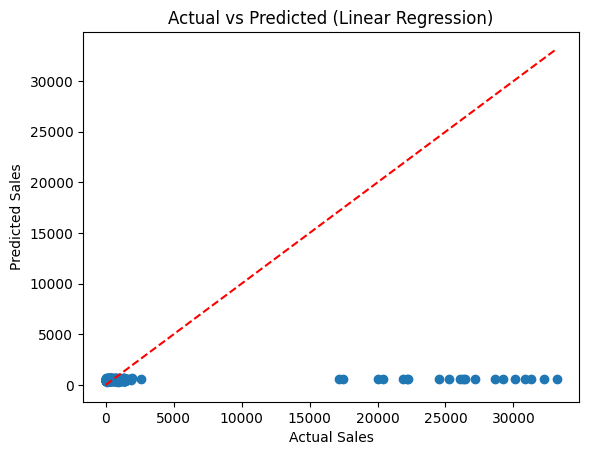

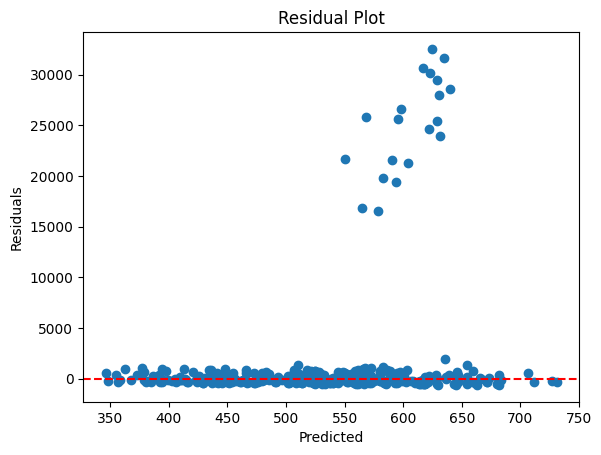

In [0]:
##linear regression assumption evaluation
import matplotlib.pyplot as plt

plt.scatter(y_test, pred_lr)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted (Linear Regression)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

residuals = y_test - pred_lr

plt.scatter(pred_lr, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Model violates the constant variance assumption and is missing important nonlinear relationships.

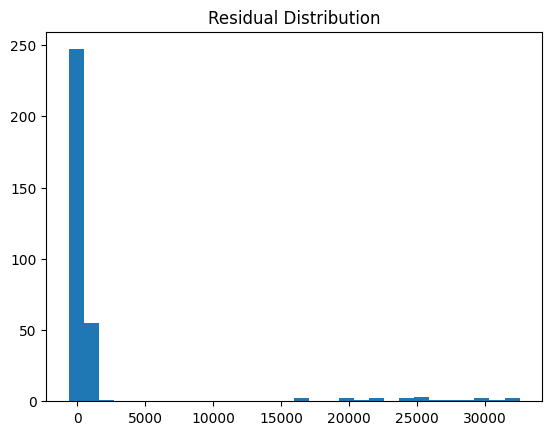

In [0]:
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

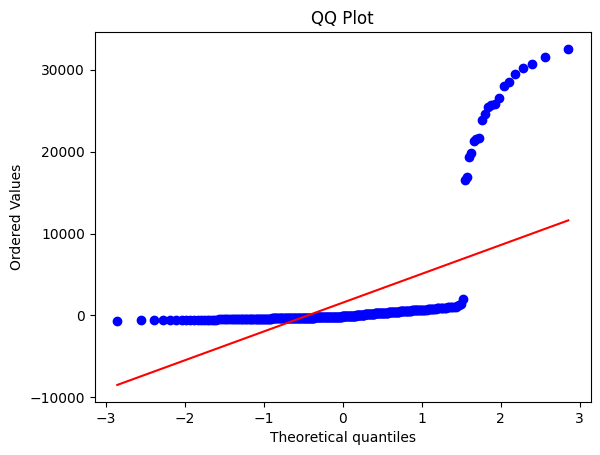

In [0]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

Residuals no longer normal or bell shaped and most points do not fall on the QQ-plot line showing non-normality.

In [0]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


X = X_train.copy()
X['intercept'] = 1

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

            feature        VIF
0          store_id   1.072511
1       day_of_week   1.010486
2             month   9.693586
3      week_of_year   9.640865
4             lag_1   1.228378
5             lag_7   1.195578
6         rolling_7   1.441860
7      avg_discount   1.012838
8  repeat_share_pct   1.077112
9         intercept  57.683626


No real issues with multicollinearity.

In [0]:
##checking feature importance
pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

avg_discount        0.187189
lag_1               0.171785
lag_7               0.150485
rolling_7           0.140318
week_of_year        0.101544
store_id            0.080192
day_of_week         0.075170
repeat_share_pct    0.064280
month               0.029038
dtype: float64